Этап 1: Знакомство с клиентами (Загрузка и .head())

Импортируйте библиотеку pandas.

Считайте файл olist_sellers_dataset.csv в DataFrame с названием sellers. Используйте для этого функцию pd.read_csv().

Выведите первые 10 строк, чтобы изучить структуру.

seller_id — уникальный идентификатор продавца.

seller_city — город, в котором зарегистрирован продавец.

In [1]:
import pandas as pd

Решение (Gemini)

Ниже приведен пример того, как аналитик подготавливает среду и делает первичный осмотр данных.

In [5]:
#import pandas as pd
# Загружаем данные
customers = pd.read_csv('olist_customers_dataset.csv')
# Смотрим "голову" таблицы
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Мой код

Задание 1. Загрузка данных о продавцах.

Загрузи файл olist_sellers_dataset.csv в переменную sellers и выведи первые 10 строк. Проверь, какие города (seller_city) там встречаются.

In [9]:
sellers = pd.read_csv('olist_sellers_dataset.csv')
sellers.head(10)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
5,c240c4061717ac1806ae6ee72be3533b,20920,rio de janeiro,RJ
6,e49c26c3edfa46d227d5121a6b6e4d37,55325,brejao,PE
7,1b938a7ec6ac5061a66a3766e0e75f90,16304,penapolis,SP
8,768a86e36ad6aae3d03ee3c6433d61df,1529,sao paulo,SP
9,ccc4bbb5f32a6ab2b7066a4130f114e3,80310,curitiba,PR


Этап 2: Фильтрация и «грязные» данные
Помнишь скрин про «бессмысленные значения» в зарплатах? В реальных данных всегда есть мусор. В бразильском датасете нас интересуют платежи.

Пример (Gemini)

Загрузим olist_order_payments_dataset.csv и посмотрим общую статистику по суммам через .describe(), как это делали в твоем курсе.

In [2]:
payments = pd.read_csv('olist_order_payments_dataset.csv')
payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Что это значит: Если мы увидим минимальное значение 0 или отрицательное, это повод задуматься: «А был ли платеж?». Если сумма 0, возможно, это подарок или ошибка системы.

Мой код

Используя метод .value_counts(), как в твоем курсе, посчитай, сколько раз встречается каждый тип оплаты (payment_type).

Найди самый популярный способ оплаты в Бразилии.

In [3]:
#payments.head()
payments['payment_type'].value_counts().head(10)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [4]:
#версия от жемини

# Посчитаем количество каждого типа оплаты
payment_counts = payments['payment_type'].value_counts()

# Выведем результат
print(payment_counts)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


Этап 3: Великое объединение (Merge)
Это самая сложная и важная часть, как в твоем задании №8. 

Нам нужно соединить заказы с платежами, чтобы понять, сколько денег принес конкретный заказ. На твоей схеме эти таблицы соединяются по полю order_id.

Пример (Gemini):
Соединим таблицу заказов (orders) и платежей (payments).

In [5]:
orders = pd.read_csv('olist_orders_dataset.csv')
# Объединяем по order_id, используем how='left', чтобы не потерять заказы без оплаты
df = pd.merge(orders, payments, on='order_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12


Зачем это: Теперь в одной строке у нас есть и дата заказа, и сумма, которую человек заплатил. 
Мы можем считать AOV (Average Order Value) — средний чек.Твоя очередь 

(Задание №3):Загрузи таблицу товаров olist_products_dataset.csv в переменную products.
Загрузи таблицу элементов заказа olist_order_items_dataset.csv в переменную items.
Соедини их по полю product_id.Выведи head(), чтобы убедиться, 
что теперь у каждого товара в заказе видна его категория (product_category_name).

Мой код

3.1 Задание: «Кто приносит деньги?»

Возьми таблицу заказов (olist_orders_dataset.csv) и платежей (olist_order_payments_dataset.csv).

Соедини их по order_id (как в задании №8 твоего курса).

Посчитай, какой средний чек у заказов, оплаченных кредитной картой (credit_card), а какой — ваучером (voucher).

Используй .groupby() и .mean(), как на твоем скрине с зарплатами.

Почему это важно: На собесе тебя спросят: «Как тип оплаты влияет на выручку?». И ты не просто вспомнишь код, а вспомнишь цифры, которые сама посчитала.

In [10]:
orders = pd.read_csv('olist_orders_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
df = pd.merge(orders, payments, on = 'order_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12


In [30]:
target_payments = df[df['payment_type'].isin(['credit_card', 'voucher'])]
target_payments['payment_type'].head()

0    credit_card
1        voucher
2        voucher
4    credit_card
5    credit_card
Name: payment_type, dtype: object

In [31]:
result = target_payments.groupby('payment_type')['payment_value'].mean()
result.head()
#print (result)

payment_type
credit_card    163.319021
voucher         65.703354
Name: payment_value, dtype: float64

Твое задание на «подумать» (Level Up)
Представь, что на собесе Т-Банка тебе говорят:

«У нас есть подозрение, что заказы, которые долго доставляются, чаще оплачиваются наличкой (boleto в Бразилии), а быстрые — картой. Проверь это».

У тебя в df после мерджа есть order_purchase_timestamp (когда купили) и order_delivered_customer_date (когда привезли).

Твой план (попробуй набросать логику или код):

Как создать колонку delivery_time? (Подсказка: просто вычти одну дату из другой, Пандас умеет в арифметику дат).

По чему ты будешь группировать в этот раз?

Какое среднее значение ты будешь считать?

In [6]:
orders = pd.read_csv('olist_orders_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
df = pd.merge(orders, payments, on = 'order_id', how='left')
#df.head()
#df[df['order_purchase_timestamp'] > '2017'].agg(['head']) #хз че это бауюсь прост

#списком короче надо писать чтоб сразу несколько колонок выбрать
#df[['order_purchase_timestamp', 'order_delivered_customer_date']].head() 

In [66]:
#order_purshape_timestamp = pd.to_datetime(df['order_purchase_timestamp'])
#order_delivered_customer_date = pd.to_datetime(df['order_delivered_customer_date'])
#delivery_time = order_delivered_customer_date - order_purshape_timestamp
#print (delivery_time) #тут сделала через переменные и это не оч круто т.к по факту она живет отдельно от самой таблицы

0         8 days 10:28:40
1         8 days 10:28:40
2         8 days 10:28:40
3        13 days 18:46:08
4         9 days 09:27:40
               ...       
103882    8 days 05:13:56
103883   22 days 04:38:58
103884   24 days 20:37:34
103885   17 days 02:04:27
103886    7 days 16:11:00
Length: 103887, dtype: timedelta64[ns]


In [7]:
#перевожу в даты прямо внутри таблицы
df['order_purshape_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

#сразу же создаю новую колонку delivery_time внутри таблицы
df['delivery_time'] = df['order_delivered_customer_date'] - df['order_purshape_timestamp']
df[['payment_type','delivery_time']].head(10)

,payment_type,delivery_time
0,credit_card,8 days 10:28:40
1,voucher,8 days 10:28:40
2,voucher,8 days 10:28:40
3,boleto,13 days 18:46:08
4,credit_card,9 days 09:27:40
5,credit_card,13 days 05:00:36
6,credit_card,2 days 20:58:23
7,credit_card,16 days 13:00:50
8,credit_card,NaT
9,credit_card,9 days 23:45:21


In [8]:
import matplotlib.pyplot as plt

In [9]:
result = df.groupby('payment_type')['delivery_time'].mean()
result.head()

payment_type
boleto        13 days 11:48:24.460424157
credit_card   12 days 08:40:41.524529060
debit_card    10 days 19:01:36.314478114
not_defined                          NaT
voucher       12 days 16:32:19.503914072
Name: delivery_time, dtype: timedelta64[ns]

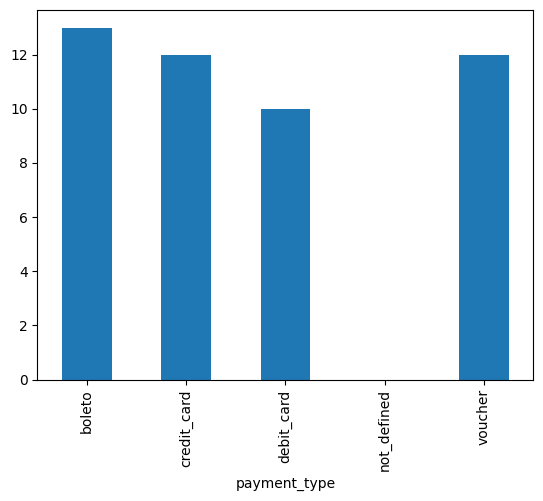

In [11]:
result = df.groupby('payment_type')['delivery_time'].mean()
# Переведем время в числа (дни), чтобы графику было легче рисовать
result_days = result.dt.days 
result_days.plot(kind='bar')
plt.show() # Явно просим показать окно с графиком